# Electricity Incident Prediction - Quick EDA and Results

This notebook helps inspect the generated dataset and baseline model behavior.

## Raw demand dataset

Auxiliary functions to plot data from raw and supervised datasets

In [339]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
DEMAND_PATH = ROOT / "data" / "raw" / "demand_2021_2025.csv"
SUP_PATH    = ROOT / "data" / "processed" / "supervised_2021_2025.csv"

def load_demand(path: Path | str = None):
    path = Path(path) if path is not None else DEMAND_PATH
    df = pd.read_csv(path)
    date_candidates = [c for c in df.columns if any(k in c.lower() for k in ("time", "date", "ts", "datetime"))]
    date_col = date_candidates[0] if date_candidates else df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce", utc=True)
    df = df.set_index(date_col).sort_index()
    demand_candidates = [c for c in df.columns if any(k in c.lower() for k in ("demand", "load", "mw"))]
    if not demand_candidates:
        demand_candidates = df.select_dtypes("number").columns.tolist()
    demand_col = demand_candidates[0]
    return df, demand_col

def load_incidents(path: Path | str = None):
    path = Path(path) if path is not None else SUP_PATH
    sup = pd.read_csv(path)
    # expect a timestamp column named like 'timestamp_target_start'
    ts_col = next((c for c in sup.columns if "timestamp" in c.lower()), None)
    if ts_col is None:
        raise ValueError("Could not find a timestamp column in supervised file")
    sup[ts_col] = pd.to_datetime(sup[ts_col], errors="coerce", utc=True)
    incidents = sup[sup.get("target", 0) == 1].copy()
    incidents = incidents.rename(columns={ts_col: "ts"})
    incidents = incidents.sort_values("ts")
    return incidents

def plot_demand(df, demand_col, incidents=None, start_date=None, end_date=None,
                ax=None, figsize=(14,4), title=None, incident_marker=dict(color="red", s=30, zorder=5)):
    start = pd.to_datetime(start_date, utc=True) if start_date is not None else df.index.min()
    end   = pd.to_datetime(end_date,   utc=True) if end_date   is not None else df.index.max()
    start = max(start, df.index.min())
    end   = min(end, df.index.max())
    if start > end:
        raise ValueError("start_date must be before end_date after clipping to data range")
    subset = df.loc[start:end, demand_col]

    created_ax = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_ax = True

    subset.plot(ax=ax, label="Demand")
    ax.set_xlabel("Time")
    ax.set_ylabel(demand_col)

    if incidents is not None and not incidents.empty:
        # get incident timestamps in range
        inc_ts = pd.to_datetime(incidents["ts"], utc=True)
        inc_ts = inc_ts[(inc_ts >= start) & (inc_ts <= end)]
        if not inc_ts.empty:
            # pick demand values at/near incident timestamps (nearest index)
            demand_series = df[demand_col]
            # reindex with nearest (data is hourly)
            demand_at_inc = demand_series.reindex(inc_ts, method="nearest")
            ax.scatter(demand_at_inc.index, demand_at_inc.values,
                       label="Incidents", **incident_marker)
    ax.legend()
    ax.set_title(title or f"Demand ({start.date()} — {end.date()})")
    if created_ax:
        plt.tight_layout()
        plt.show()
    return ax

def plot_week_offset_periods(
    df,
    demand_col,
    periods,
    ax=None,
    figsize=(14, 5),
    title=None,
    legend_title="Periods",
):
    """
    Plot multiple custom periods in a single chart for direct comparison.

    Parameters
    ----------
    df : pd.DataFrame
        Time-indexed demand dataframe.
    demand_col : str
        Demand column name.
    periods : list[tuple]
        Period definitions to compare.
        Each item can be (start, end) or (start, end, label).
    """
    created_ax = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_ax = True

    plotted = 0
    for i, period in enumerate(periods):
        if len(period) not in (2, 3):
            raise ValueError("Each period must be (start, end) or (start, end, label)")

        period_start = pd.to_datetime(period[0], utc=True)
        period_end = pd.to_datetime(period[1], utc=True)
        if period_start >= period_end:
            raise ValueError("Each period start must be before period end")

        line_label = period[2] if len(period) == 3 else f"Period {i + 1}"

        # Keep only data available in the dataframe bounds.
        period_start = max(period_start, df.index.min())
        period_end = min(period_end, df.index.max())
        if period_start >= period_end:
            continue

        subset = df.loc[period_start:period_end, demand_col]
        if subset.empty:
            continue

        elapsed_hours = (subset.index - subset.index[0]).total_seconds() / 3600.0
        ax.plot(elapsed_hours, subset.values, label=line_label, linewidth=2)
        plotted += 1

    if plotted == 0:
        raise ValueError("No data points were found for the requested periods")

    ax.set_xlabel("Hours since period start")
    ax.set_ylabel(demand_col)
    ax.set_title(title or "Demand comparison across selected periods")
    ax.grid(True, alpha=0.25)
    ax.legend(title=legend_title)

    if created_ax:
        plt.tight_layout()
        plt.show()

    return ax

In [340]:
df = pd.read_csv(DEMAND_PATH)
df.head()

,datetime,demand_mw
0,2021-01-01 00:00:00+01:00,24656.632
1,2021-01-01 01:00:00+01:00,23383.418
2,2021-01-01 02:00:00+01:00,21273.532
3,2021-01-01 03:00:00+01:00,19589.138
4,2021-01-01 04:00:00+01:00,18755.911


In [341]:
print("Rows:", len(df))

Rows: 43824


### Demand from 2021 to 2025

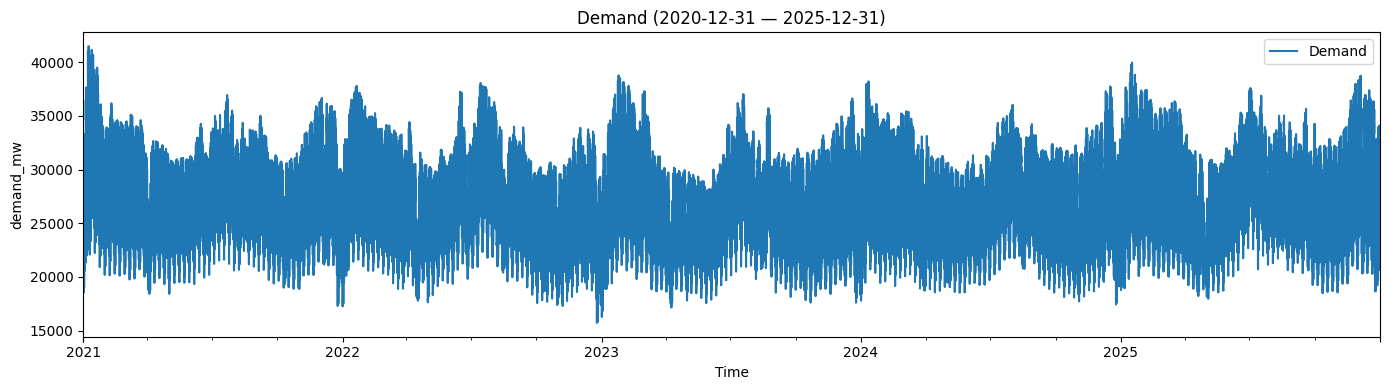

<Axes: title={'center': 'Demand (2020-12-31 — 2025-12-31)'}, xlabel='Time', ylabel='demand_mw'>

In [342]:
# load data
df_demand, demand_col = load_demand()

# whole timeline
plot_demand(df_demand, demand_col)

### Anual comparison

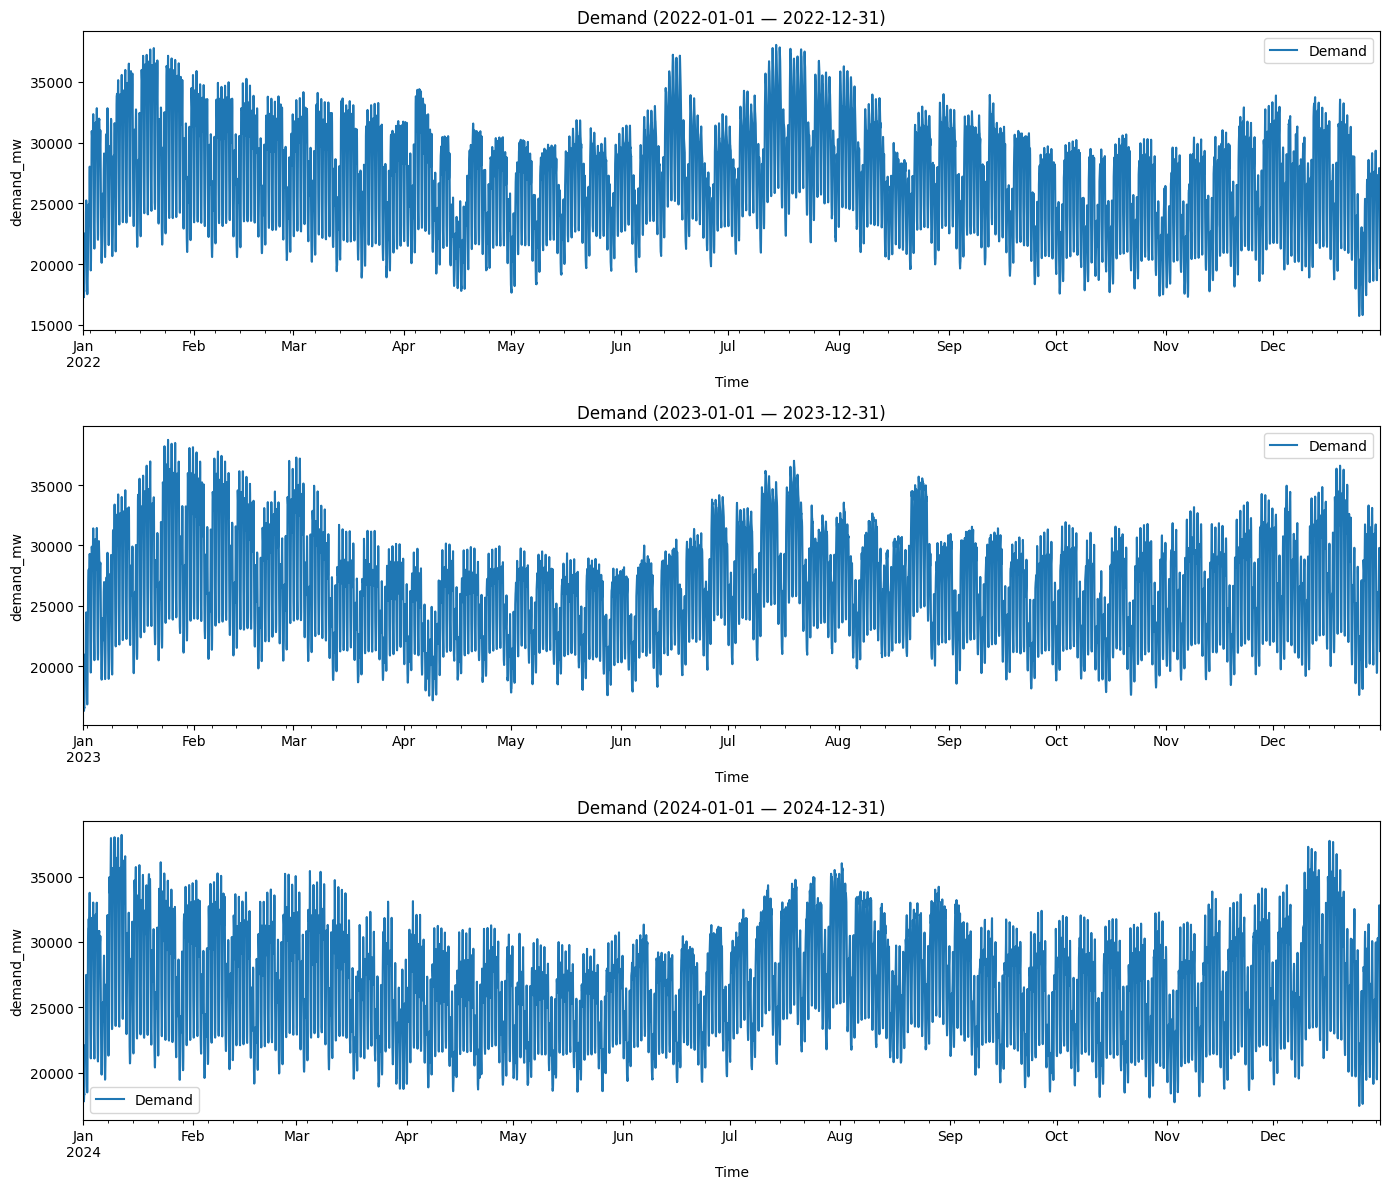

In [343]:
# multiple periods (stacked plots)
periods = [
    ("2022-01-01", "2022-12-31"),
    ("2023-01-01", "2023-12-31"),
    ("2024-01-01", "2024-12-31"),
]
fig, axes = plt.subplots(len(periods), 1, figsize=(14, 4 * len(periods)), squeeze=False)
for ax, (s, e) in zip(axes.ravel(), periods):
    plot_demand(df_demand, demand_col, start_date=s, end_date=e, ax=ax)
plt.tight_layout()
plt.show()

## Incidents dataset

In [344]:
df = pd.read_csv(SUP_PATH)
df.head()

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,lag_161,lag_162,lag_163,lag_164,lag_165,lag_166,lag_167,lag_168,target,timestamp_target_start
0,32154.515,35872.538,38906.749,39936.377,39838.223,39391.774,38427.044,38437.059,39148.044,40392.968,...,19234.177,18764.257,18521.015,18755.911,19589.138,21273.532,23383.418,24656.632,0,2021-01-07T23:00:00Z
1,29265.563,32154.515,35872.538,38906.749,39936.377,39838.223,39391.774,38427.044,38437.059,39148.044,...,19394.375,19234.177,18764.257,18521.015,18755.911,19589.138,21273.532,23383.418,0,2021-01-08T00:00:00Z
2,26788.346,29265.563,32154.515,35872.538,38906.749,39936.377,39838.223,39391.774,38427.044,38437.059,...,20605.308,19394.375,19234.177,18764.257,18521.015,18755.911,19589.138,21273.532,0,2021-01-08T01:00:00Z
3,25473.496,26788.346,29265.563,32154.515,35872.538,38906.749,39936.377,39838.223,39391.774,38427.044,...,22990.898,20605.308,19394.375,19234.177,18764.257,18521.015,18755.911,19589.138,0,2021-01-08T02:00:00Z
4,24862.779,25473.496,26788.346,29265.563,32154.515,35872.538,38906.749,39936.377,39838.223,39391.774,...,24930.918,22990.898,20605.308,19394.375,19234.177,18764.257,18521.015,18755.911,0,2021-01-08T03:00:00Z


In [345]:
print("Rows:", len(df))
print("Positive rate:", df["target"].mean())

Rows: 43650
Positive rate: 0.15942726231386026


### When do alerts happen most?

Simple counts by weekday and month for rows labeled as alerts (`target == 1`).

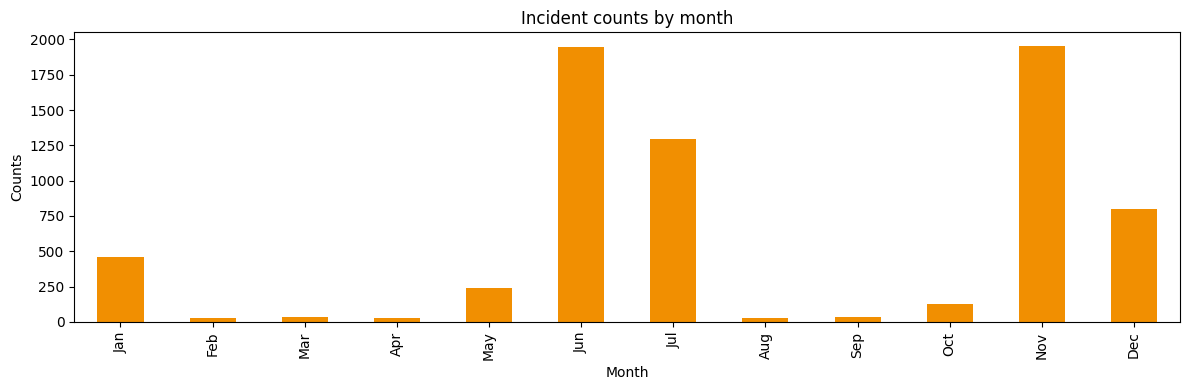

In [346]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

# use existing df if present, otherwise load
try:
    df
except NameError:
    df = pd.read_csv(
        "data/processed/supervised_2021_2025.csv",
        parse_dates=["timestamp_target_start"],
    )

# ensure timestamp is datetime
if not np.issubdtype(df.timestamp_target_start.dtype, np.datetime64):
    df["timestamp_target_start"] = pd.to_datetime(df["timestamp_target_start"])

df["month"] = df.timestamp_target_start.dt.month_name().str[:3]
df["year"] = df.timestamp_target_start.dt.year

inc = df[df.target == 1]
month_order = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

# counts and normalized rates
month_counts = inc.month.value_counts().reindex(month_order, fill_value=0)
month_totals = df.month.value_counts().reindex(month_order, fill_value=0)
month_rate = month_counts / month_totals.replace(0, np.nan)

# plots
fig, ax = plt.subplots(figsize=(12, 4))
month_counts.plot(kind="bar", color="#F18F01", ax=ax)
ax.set_title("Incident counts by month")
ax.set_xlabel("Month")
ax.set_ylabel("Counts")


plt.tight_layout()
plt.show()

Coldest months (June, July) and hottest months (November, December) are among the most electricity consuming periods.

### When summer is arriving, alerts appear

Let us see how incidents relate with the electricity demand.

The following plot shows 'alerts' as red dots overlapped with the demand per hour. Each 'alert' represents that an incident happened within the next (0-6) hours from it.

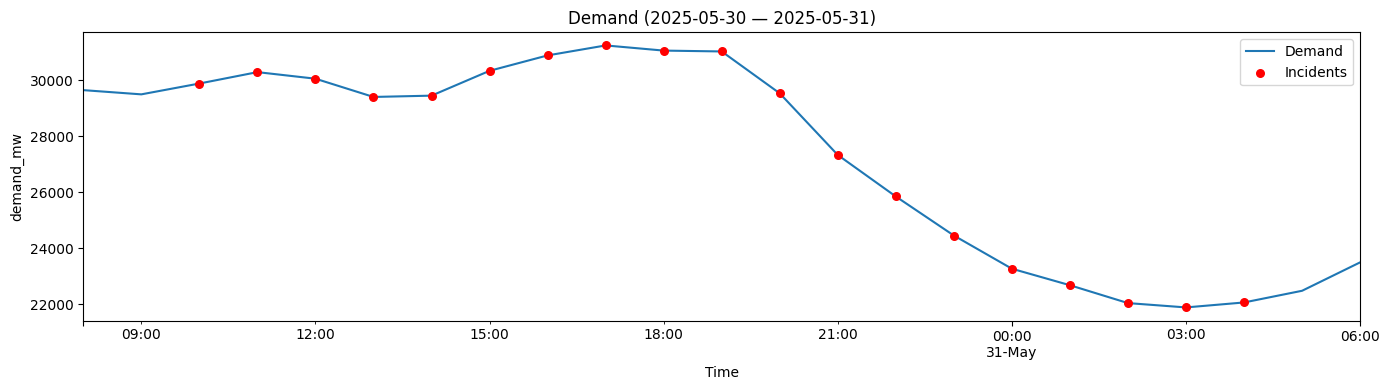

<Axes: title={'center': 'Demand (2025-05-30 — 2025-05-31)'}, xlabel='Time', ylabel='demand_mw'>

In [347]:
df_demand, demand_col = load_demand()
incidents = load_incidents()

# specific period
plot_demand(
    df_demand,
    demand_col,
    incidents=incidents,
    start_date="2025-05-30 10:00:00+02:00", end_date="2025-05-31 08:00:00+02:00",
)

In the following plot we can see how the demand changed in that same period during the previous 4 weeks. 


Notice that the first 'alert' point was at 10hs (see the 'red dots' plot); so an incident happened 6 hours later. In the below plot, after x=6, we can see that the demand of the analyzed period (blue line) starts to reach a high difference with the others, representing a demand increase with respect to previous data.

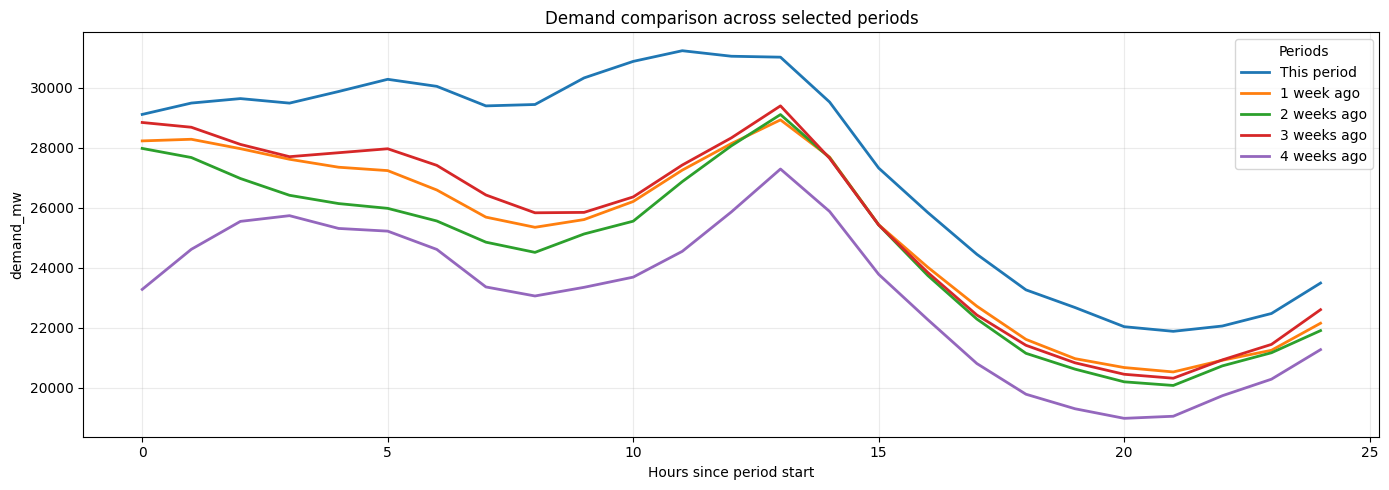

<Axes: title={'center': 'Demand comparison across selected periods'}, xlabel='Hours since period start', ylabel='demand_mw'>

In [348]:
plot_week_offset_periods(
    df_demand,
    demand_col,
    periods=[
        ("2025-05-30 08:00:00+02:00", "2025-05-31 08:00:00+02:00", "This period"),
        ("2025-05-23 08:00:00+02:00", "2025-05-24 08:00:00+02:00", "1 week ago"),
        ("2025-05-16 08:00:00+02:00", "2025-05-17 08:00:00+02:00", "2 weeks ago"),
        ("2025-05-09 08:00:00+02:00", "2025-05-10 08:00:00+02:00", "3 weeks ago"),
        ("2025-05-02 08:00:00+02:00", "2025-05-03 08:00:00+02:00", "4 weeks ago"),
    ],
)

### When summer is ending, alerts disappear

No incident alerts appear when summer is ending, since demand is noticeable lower than previous weeks.

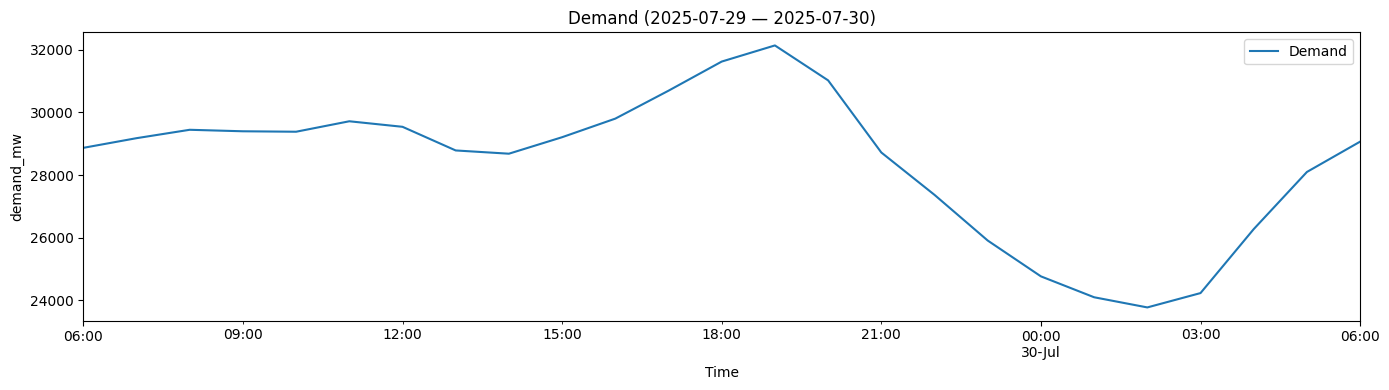

<Axes: title={'center': 'Demand (2025-07-29 — 2025-07-30)'}, xlabel='Time', ylabel='demand_mw'>

In [349]:
# specific period
plot_demand(
    df_demand,
    demand_col,
    incidents=incidents,
    start_date="2025-07-29 08:00:00+02:00",
    end_date="2025-07-30 08:00:00+02:00",
)

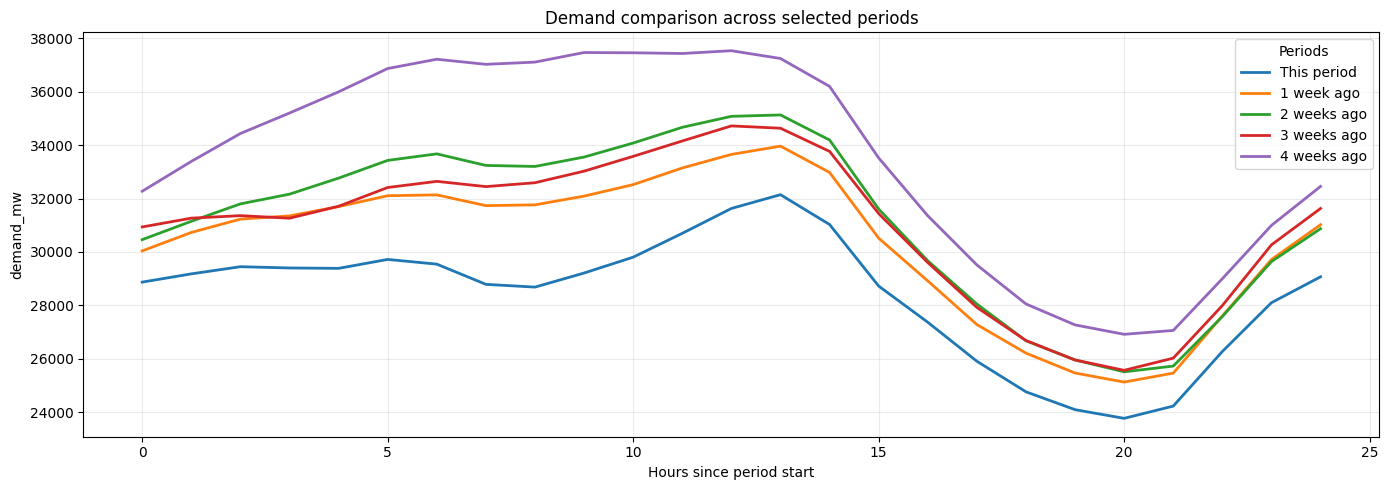

<Axes: title={'center': 'Demand comparison across selected periods'}, xlabel='Hours since period start', ylabel='demand_mw'>

In [350]:
plot_week_offset_periods(
    df_demand,
    demand_col,
    periods=[
        ("2025-07-29 08:00:00+02:00", "2025-07-30 08:00:00+02:00", "This period"),
        ("2025-07-22 08:00:00+02:00", "2025-07-23 08:00:00+02:00", "1 week ago"),
        ("2025-07-15 08:00:00+02:00", "2025-07-16 08:00:00+02:00", "2 weeks ago"),
        ("2025-07-08 08:00:00+02:00", "2025-07-09 08:00:00+02:00", "3 weeks ago"),
        ("2025-07-01 08:00:00+02:00", "2025-07-02 08:00:00+02:00", "4 weeks ago"),
    ],
)

### Other seasons

Demand not only increases in hotter/colder seasons, but in other non-trivial periods of the year. In this case, we show an increase in 2025-03-18, where incident alerts are raised because of the abnormality of the demand.

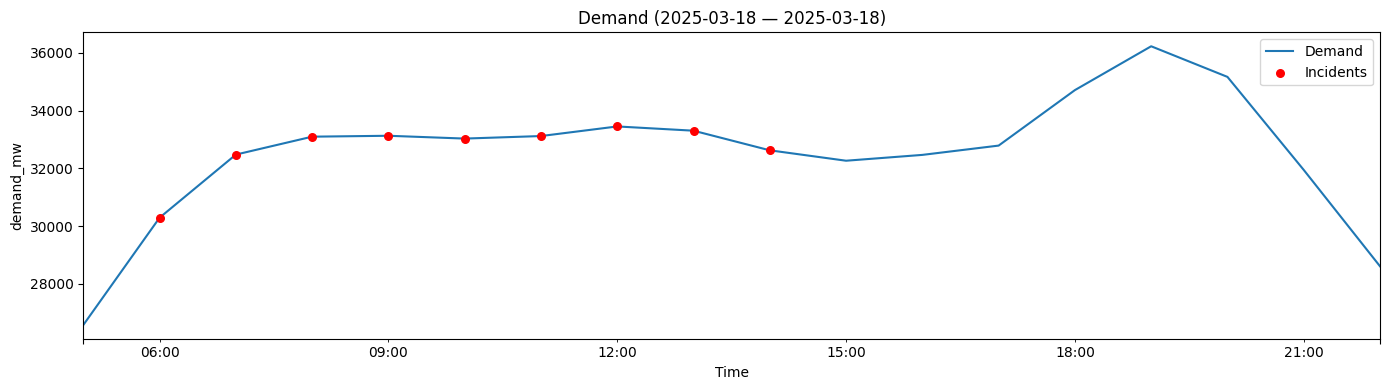

<Axes: title={'center': 'Demand (2025-03-18 — 2025-03-18)'}, xlabel='Time', ylabel='demand_mw'>

In [376]:
df_demand, demand_col = load_demand()
incidents = load_incidents()

# specific period
plot_demand(
    df_demand,
    demand_col,
    incidents=incidents,
    start_date="2025-03-18 06:00:00+01:00",
    end_date="2025-03-18 23:00:00+01:00",
)

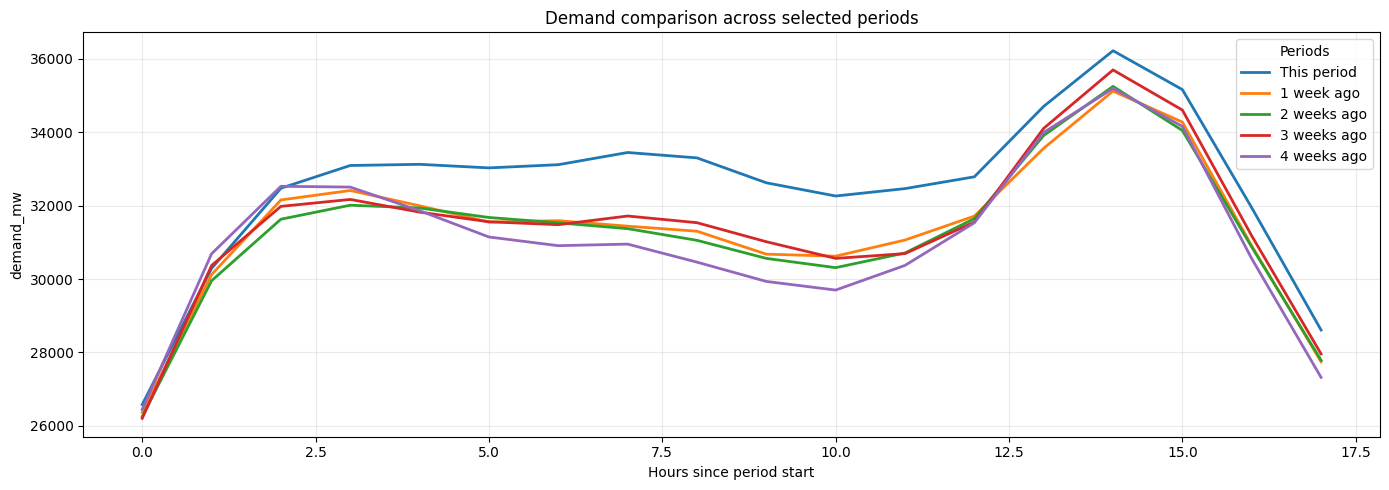

<Axes: title={'center': 'Demand comparison across selected periods'}, xlabel='Hours since period start', ylabel='demand_mw'>

In [380]:
plot_week_offset_periods(
    df_demand,
    demand_col,
    periods=[
        ("2025-03-18 06:00:00+01:00", "2025-03-18 23:00:00+01:00", "This period"),
        ("2025-03-11 06:00:00+01:00", "2025-03-11 23:00:00+01:00", "1 week ago"),
        ("2025-03-04 06:00:00+01:00", "2025-03-04 23:00:00+01:00", "2 weeks ago"),
        ("2025-02-25 06:00:00+01:00", "2025-02-25 23:00:00+01:00", "3 weeks ago"),
        ("2025-02-18 06:00:00+01:00", "2025-02-18 23:00:00+01:00", "4 weeks ago"),
    ],
)